<div style="border-radius:10px; border:black solid; padding: 15px; background-color: Green; font-size:100%; text-align:left">
<p style="font-family:Georgia; font-weight:bold; letter-spacing: 2px; color:white; font-size:200%; text-align:center;padding: 0px;"> Mall Customer Segmentation.</p></div>

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 Business Objective:</font></h3>
   
- The main objective of this task is to segment customers into distinct groups based on their purchasing behavior, demographics, and spending patterns. By identifying patterns in customer behavior, the business can create targeted marketing strategies, improve customer satisfaction, and enhance revenue.

<h3 align="left"><font color=brown>📊 Business Value:</font></h3>

- Customer segmentation helps businesses create personalized marketing campaigns, improving customer engagement and retention. It enables efficient resource allocation by targeting high-value customers and optimizing marketing efforts. Additionally, it identifies new market opportunities and enhances cross-selling, driving revenue growth and customer satisfaction.

## **Import Needed Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

### **Data Representation**

In [2]:
# Load the dataset
df = pd.read_csv("/kaggle/input/mall-customers-segmentation/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## **Data Wrangling**

**Missing Values**

In [5]:
df.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

**Duplicated Values**

In [6]:
df.duplicated().sum()

0

## **Exploratory Data Analysis**

#### **Univariate Analysis**

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


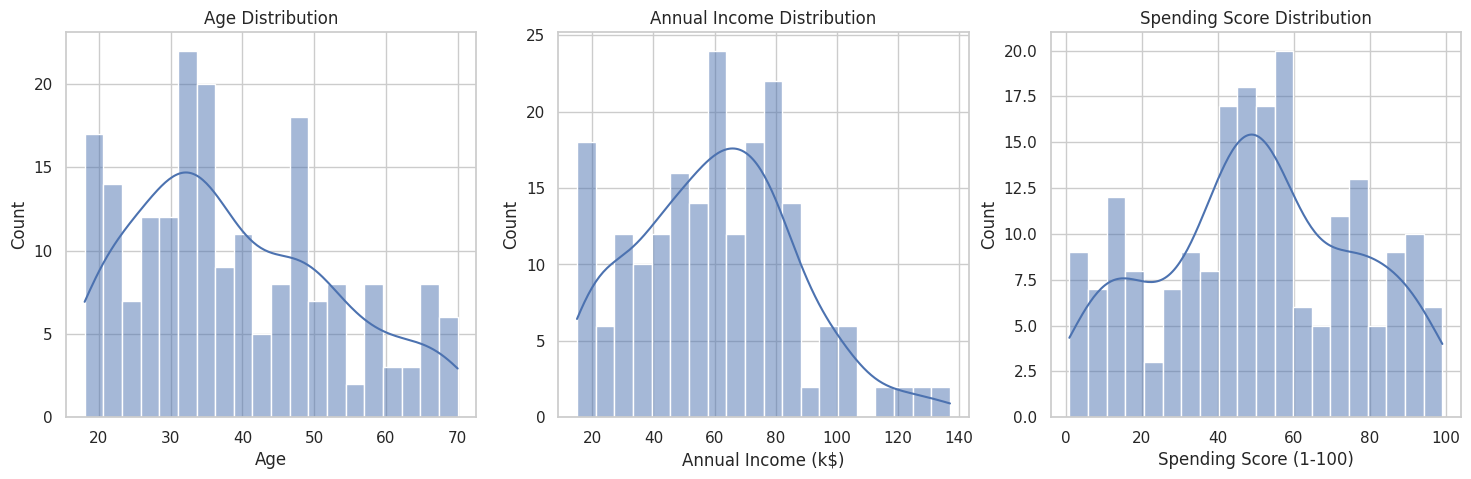

In [7]:
# Distribution Analysis
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axs[0])
axs[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axs[1])
axs[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axs[2])
axs[2].set_title('Spending Score Distribution')

plt.show()

#### **Bivariate Analysis**

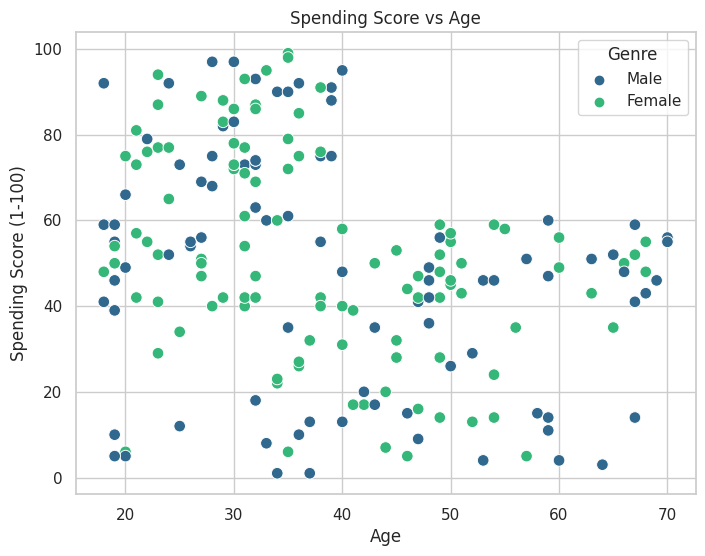

In [8]:
# Scatter Plot: Age vs. Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Genre', palette='viridis', s=70)
plt.title('Spending Score vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

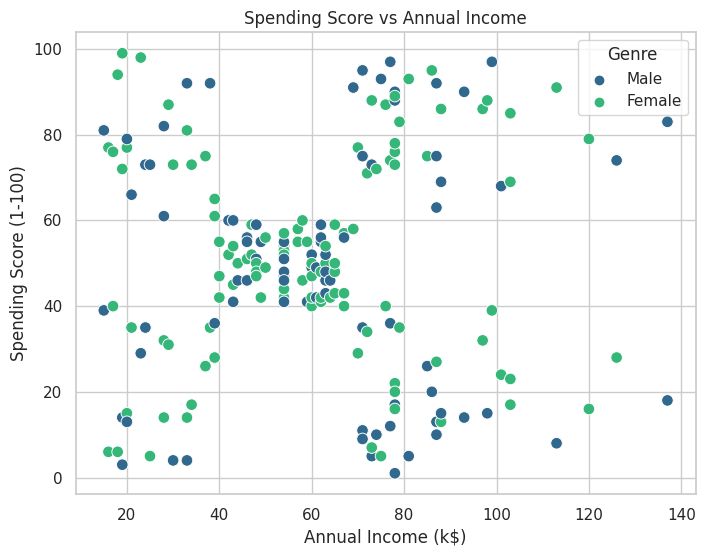

In [9]:
# Scatter Plot: Annual Income vs. Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', palette='viridis', s=70)
plt.title('Spending Score vs Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

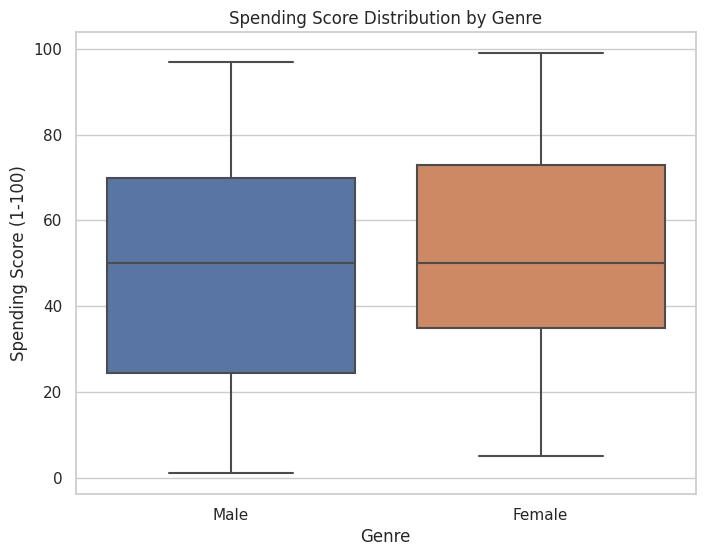

In [10]:
# Box Plot: Spending Score by Genre
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Genre', y='Spending Score (1-100)')
plt.title('Spending Score Distribution by Genre')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


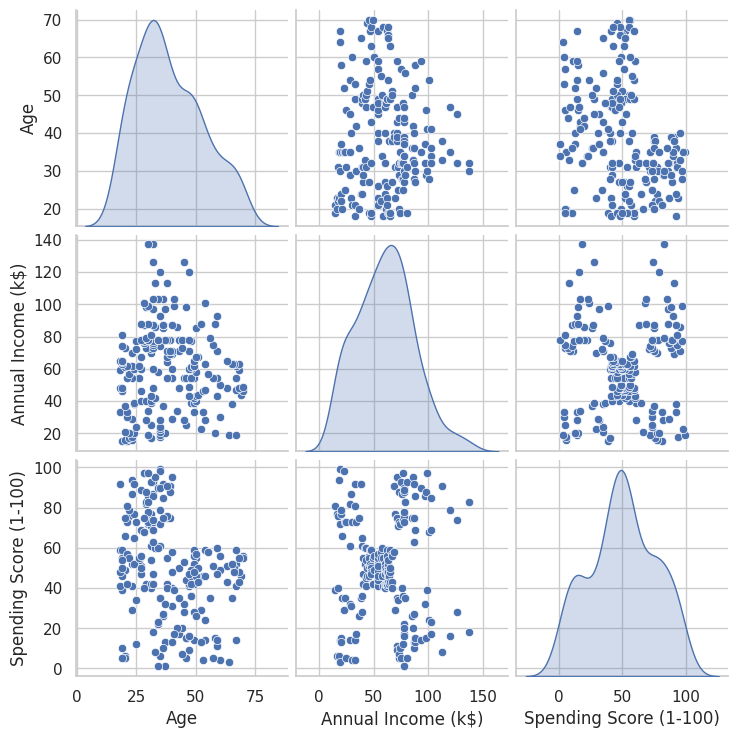

In [11]:
# Pair Plot: Visualizing Relationships across Multiple Features
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], diag_kind='kde')
plt.show()

#### **Multivariate Analysis**

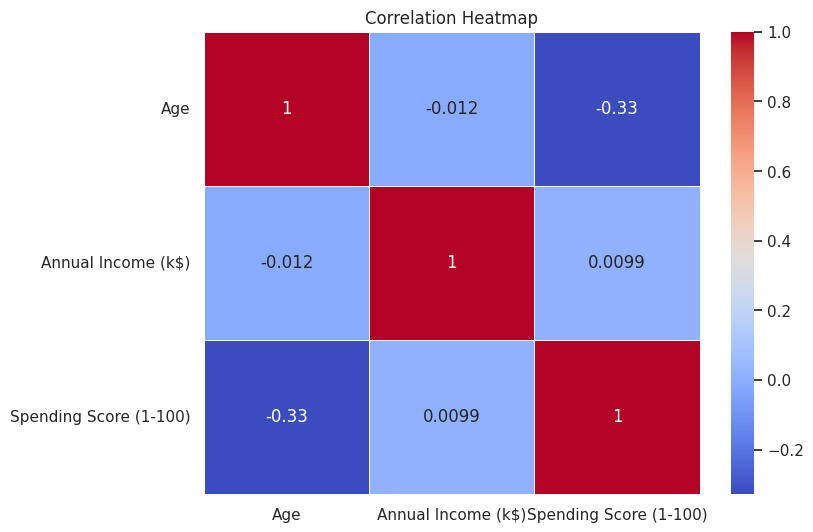

In [12]:
# Correlation Heatmap (Numerical Features)
plt.figure(figsize=(8, 6))
correlation = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## **Preprocessing**

#### **Drop Unneeded Columns**

In [13]:
# Drop CustomerID (irrelevant for ML)
df.drop(columns=['CustomerID'], inplace=True)

#### **Data Encoding**

In [14]:
# Encode the 'Genre' column
label_encoder = LabelEncoder()
df['Genre'] = label_encoder.fit_transform(df['Genre'])

#### **Data Scaling**

In [15]:
# Apply standard scaling
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

In [16]:
df_scaled

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

## **Data Modeling**

#### **K-Means Clustering**

**Finding Optimal Clusters using Elbow Method**

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

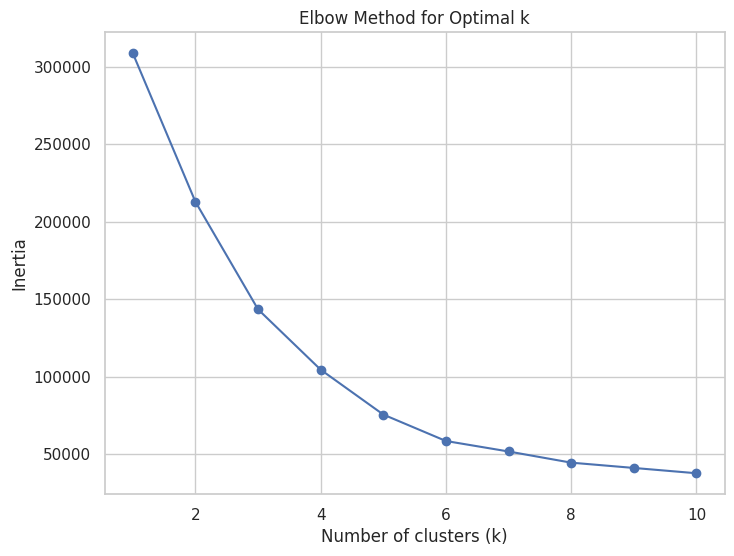

In [17]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

# Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [18]:
# Apply K-means Clustering with k=5

kmeans = KMeans(n_clusters=5, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(df)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [19]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,19,15,39,0
1,1,21,15,81,4
2,0,20,16,6,0
3,0,23,16,77,4
4,0,31,17,40,0
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,2
197,1,32,126,74,1
198,1,32,137,18,2


In [20]:
# Calculate silhouette score for K-Means
kmeans_score = silhouette_score(df, kmeans.labels_)
print(f"K-Means Silhouette Score: {kmeans_score:.2f}")

K-Means Silhouette Score: 0.44


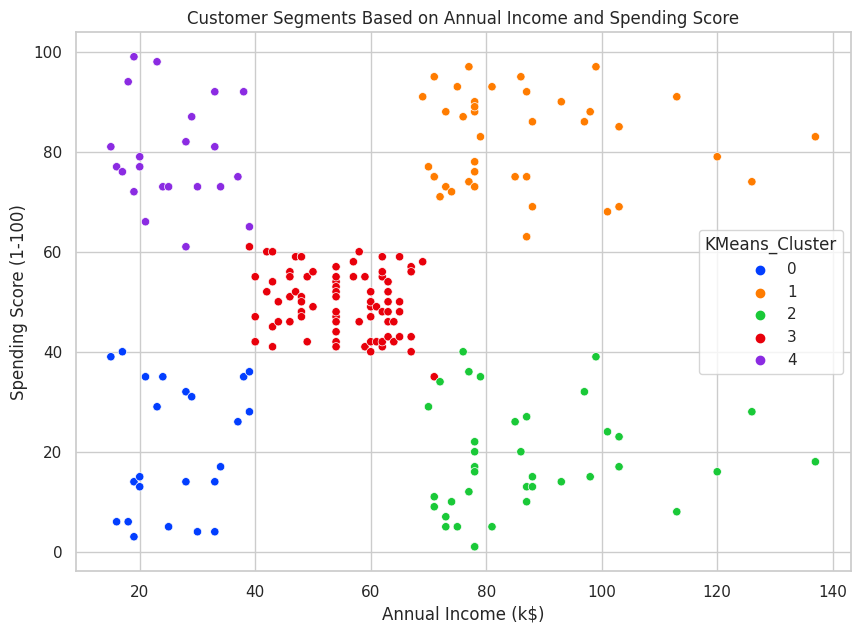

In [21]:
# 5. Visualize Clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', palette='bright')
plt.title('Customer Segments Based on Annual Income and Spending Score')
plt.show()

In [22]:
cluster_summary = df.groupby('KMeans_Cluster').agg(
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean'),
    Customer_Count=('Age', 'count')
)

cluster_summary

,Average_Age,Average_Income,Average_Spending_Score,Customer_Count
KMeans_Cluster,,,,
0,45.217391,26.304348,20.913043,23
1,32.692308,86.538462,82.128205,39
2,40.324324,87.432432,18.189189,37
3,43.126582,54.822785,49.835443,79
4,25.272727,25.727273,79.363636,22


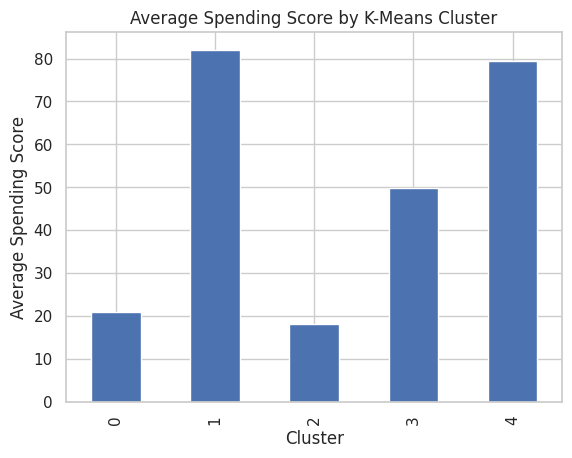

In [23]:
# Bar plot of average spending score by cluster
df.groupby('KMeans_Cluster')['Spending Score (1-100)'].mean().plot(kind='bar')
plt.title('Average Spending Score by K-Means Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Spending Score')
plt.show()

#### **Agglomerative Clustring**

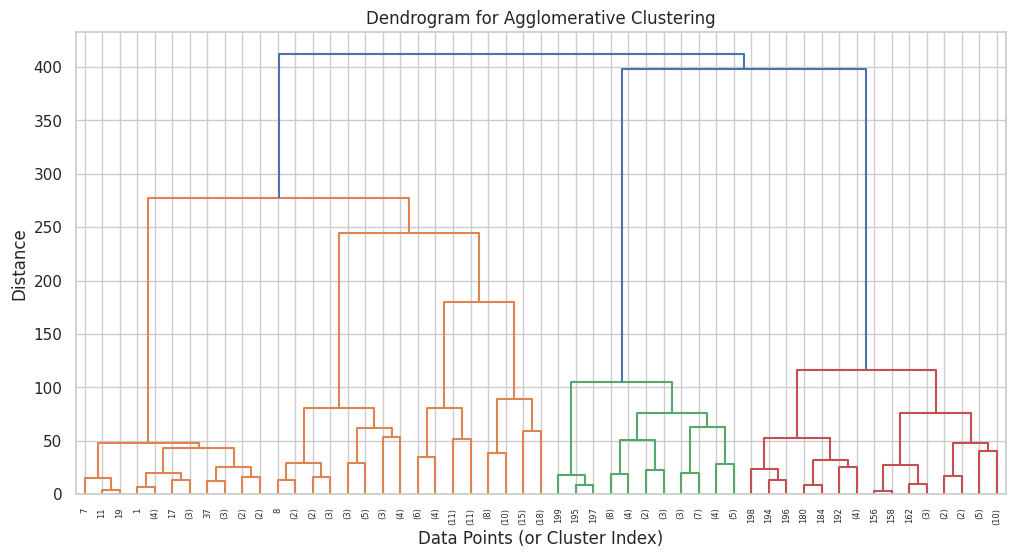

In [27]:
# Generate the linkage matrix using the 'ward' method
Z = linkage(df, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # Truncating for better visibility
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Data Points (or Cluster Index)')
plt.ylabel('Distance')
plt.show()

In [28]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,19,15,39,0
1,1,21,15,81,4
2,0,20,16,6,0
3,0,23,16,77,4
4,0,31,17,40,0
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,2
197,1,32,126,74,1
198,1,32,137,18,2


In [29]:
# Apply Agglomerative Clustering with 5 clusters
agg_clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agglomerative_Cluster'] = agg_clustering.fit_predict(df.iloc[:, :-1])

In [30]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Agglomerative_Cluster
0,1,19,15,39,0,4
1,1,21,15,81,4,3
2,0,20,16,6,0,4
3,0,23,16,77,4,3
4,0,31,17,40,0,4
...,...,...,...,...,...,...
195,0,35,120,79,1,2
196,0,45,126,28,2,1
197,1,32,126,74,1,2
198,1,32,137,18,2,1


In [31]:
# Calculate silhouette score for K-Means
agg_clustering_score = silhouette_score(df, agg_clustering.labels_)
print(f"Agg Clustering Silhouette Score: {agg_clustering_score:.2f}")

Agg Clustering Silhouette Score: 0.44


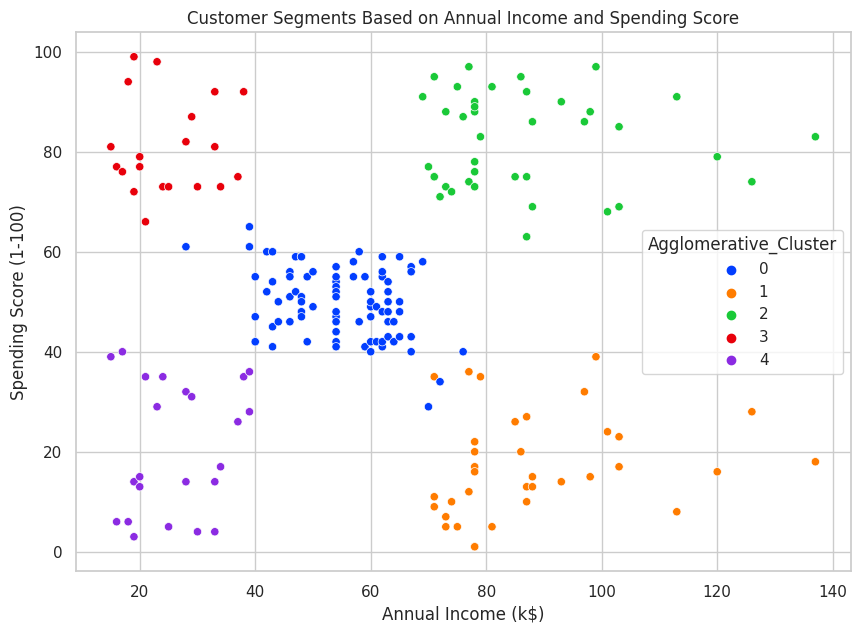

In [32]:
# Visualize Clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglomerative_Cluster', palette='bright')
plt.title('Customer Segments Based on Annual Income and Spending Score')
plt.show()

In [33]:
cluster_summary = df.groupby('Agglomerative_Cluster').agg(
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean'),
    Customer_Count=('Age', 'count')
)

cluster_summary

,Average_Age,Average_Income,Average_Spending_Score,Customer_Count
Agglomerative_Cluster,,,,
0,42.156627,54.759036,49.771084,83
1,41.685714,88.228571,17.285714,35
2,32.692308,86.538462,82.128205,39
3,24.850000,24.950000,81.000000,20
4,45.217391,26.304348,20.913043,23


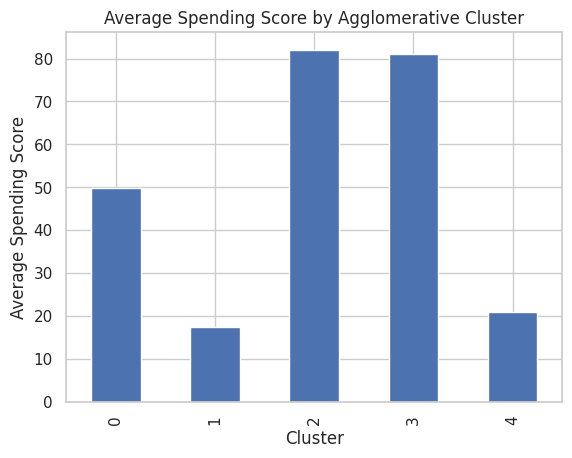

In [34]:
# Bar plot of average spending score by cluster
df.groupby('Agglomerative_Cluster')['Spending Score (1-100)'].mean().plot(kind='bar')
plt.title('Average Spending Score by Agglomerative Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Spending Score')
plt.show()

#### **DBSCAN**

**Get *eps*** **value with min_pts=5**

In [37]:
# Fit Nearest Neighbors model
k = 4  # min_samples - 1
nearest_neighbors = NearestNeighbors(n_neighbors=k)
nearest_neighbors.fit(df)

# Get the distances to the k-nearest neighbors
distances, indices = nearest_neighbors.kneighbors(df)
distances

array([[ 0.        , 12.24744871, 17.57839583, 18.78829423],
       [ 0.        ,  4.69041576,  5.47722558,  5.56776436],
       [ 0.        , 15.13274595, 18.84144368, 27.5317998 ],
       [ 0.        ,  1.73205081,  4.12310563,  4.69041576],
       [ 0.        ,  7.54983444,  9.53939201, 12.24744871],
       [ 0.        ,  1.73205081,  3.74165739,  4.35889894],
       [ 0.        ,  7.61577311, 13.07669683, 15.13274595],
       [ 0.        , 13.03840481, 13.03840481, 13.52774926],
       [ 0.        , 11.40175425, 11.74734012, 13.49073756],
       [ 0.        ,  6.244998  ,  7.21110255,  7.87400787],
       [ 0.        ,  9.16515139, 11.40175425, 15.84297952],
       [ 0.        ,  4.12310563, 13.03840481, 19.6977156 ],
       [ 0.        ,  9.        ,  9.16515139, 13.49073756],
       [ 0.        ,  3.        ,  3.74165739,  4.12310563],
       [ 0.        ,  7.61577311, 13.07669683, 15.42724862],
       [ 0.        ,  3.        ,  4.35889894,  4.69041576],
       [ 0.        ,  3.

In [38]:
indices

array([[  0,   4,  16,  20],
       [  1,   3,  15,   5],
       [  2,   6,  14,  22],
       [  3,   5,  13,  15],
       [  4,  16,  20,   0],
       [  5,   3,  13,  15],
       [  6,  14,  22,   2],
       [  7,  11,  29,   1],
       [  8,  10,  30,  12],
       [  9,  23,  21,  13],
       [ 10,  12,   8,  24],
       [ 11,  19,   7,  29],
       [ 12,  24,  10,   8],
       [ 13,  15,   5,   3],
       [ 14,   6,  22,  36],
       [ 15,  13,   5,   3],
       [ 16,  20,   4,  28],
       [ 17,  21,   5,  31],
       [ 18,  26,  28,  12],
       [ 19,  11,   7,  29],
       [ 20,  16,  28,   4],
       [ 21,  13,  23,   9],
       [ 22,  32,  34,  24],
       [ 23,  21,   9,  37],
       [ 24,  34,  12,  32],
       [ 25,  29,  35,  23],
       [ 26,  28,  18,  20],
       [ 27,  43,  23,  51],
       [ 28,  26,  20,  16],
       [ 29,  35,  25,  33],
       [ 30,  32,   8,  24],
       [ 31,  21,  39,  35],
       [ 32,  30,  22,  34],
       [ 33,  41,  29,  35],
       [ 34,  

In [44]:
distances[:, k-1]

array([18.78829423,  5.56776436, 27.5317998 ,  4.69041576, 12.24744871,
        4.35889894, 15.13274595, 13.52774926, 13.49073756,  7.87400787,
       15.84297952, 19.6977156 , 13.49073756,  4.12310563, 15.42724862,
        4.69041576, 10.24695077, 11.48912529, 15.55634919, 17.34935157,
        9.53939201,  7.21110255, 12.40967365,  9.11043358, 11.26942767,
        9.69535971, 11.22497216, 14.2126704 , 10.24695077,  8.18535277,
       11.87434209,  8.54400375, 10.81665383, 11.44552314, 10.81665383,
        8.54400375, 13.74772708, 10.63014581, 13.3041347 , 10.63014581,
       17.40689519, 12.489996  , 11.26942767,  8.1240384 , 13.3041347 ,
       11.35781669,  9.        ,  7.21110255,  9.89949494,  9.48683298,
        7.14142843, 10.81665383,  8.06225775, 10.77032961,  5.19615242,
        8.18535277,  5.19615242,  8.77496439,  7.21110255,  7.87400787,
        8.54400375,  8.54400375,  4.79583152,  9.        ,  5.91607978,
        7.07106781,  8.71779789,  5.91607978,  6.70820393,  9.43

In [45]:
k_distances = np.sort(distances[:, k - 1])
k_distances

array([ 3.74165739,  4.12310563,  4.24264069,  4.24264069,  4.35889894,
        4.35889894,  4.35889894,  4.58257569,  4.58257569,  4.58257569,
        4.58257569,  4.69041576,  4.69041576,  4.69041576,  4.69041576,
        4.69041576,  4.79583152,  4.79583152,  4.79583152,  5.        ,
        5.19615242,  5.19615242,  5.19615242,  5.29150262,  5.38516481,
        5.38516481,  5.38516481,  5.47722558,  5.47722558,  5.47722558,
        5.56776436,  5.56776436,  5.74456265,  5.91607978,  5.91607978,
        5.91607978,  5.91607978,  5.91607978,  5.91607978,  6.164414  ,
        6.164414  ,  6.164414  ,  6.244998  ,  6.244998  ,  6.244998  ,
        6.40312424,  6.40312424,  6.4807407 ,  6.63324958,  6.70820393,
        6.70820393,  6.70820393,  6.78232998,  7.07106781,  7.14142843,
        7.14142843,  7.14142843,  7.14142843,  7.14142843,  7.21110255,
        7.21110255,  7.21110255,  7.21110255,  7.21110255,  7.21110255,
        7.28010989,  7.28010989,  7.34846923,  7.34846923,  7.34

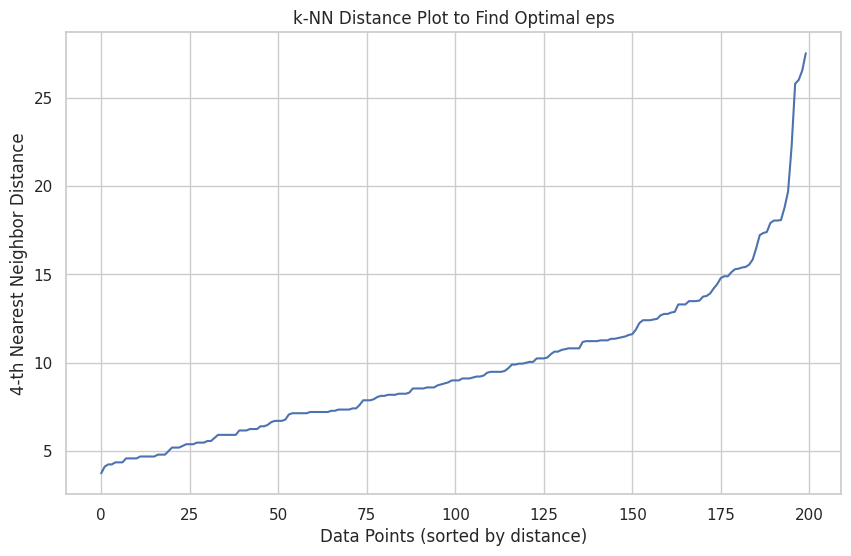

In [35]:
# Fit Nearest Neighbors model
k = 4  # min_samples - 1
nearest_neighbors = NearestNeighbors(n_neighbors=k)
nearest_neighbors.fit(df)

# Get the distances to the k-nearest neighbors
distances, indices = nearest_neighbors.kneighbors(df)

# Sort the distances for the k-th neighbor
k_distances = np.sort(distances[:, k - 1])

# Plot the k-NN distances
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title('k-NN Distance Plot to Find Optimal eps')
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.show()

**Apply DBSCAN**

In [46]:
# Apply DBSCAN
dbscan = DBSCAN(eps=12, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df.iloc[:, :-2])

In [47]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Agglomerative_Cluster,DBSCAN_Cluster
0,1,19,15,39,0,4,-1
1,1,21,15,81,4,3,0
2,0,20,16,6,0,4,-1
3,0,23,16,77,4,3,0
4,0,31,17,40,0,4,1
...,...,...,...,...,...,...,...
195,0,35,120,79,1,2,-1
196,0,45,126,28,2,1,-1
197,1,32,126,74,1,2,-1
198,1,32,137,18,2,1,-1


In [48]:
dbscan_labels = df['DBSCAN_Cluster']
valid_mask = dbscan_labels != -1  # Boolean mask for valid clusters
valid_features = df[valid_mask]
valid_labels = dbscan_labels[valid_mask]

In [49]:
# Calculate silhouette score only if there are valid clusters
if len(np.unique(valid_labels)) > 1:
    dbscan_score = silhouette_score(valid_features, valid_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.2f}")
else:
    print("DBSCAN produced too many noise points. No valid clusters found.")

DBSCAN Silhouette Score: 0.34


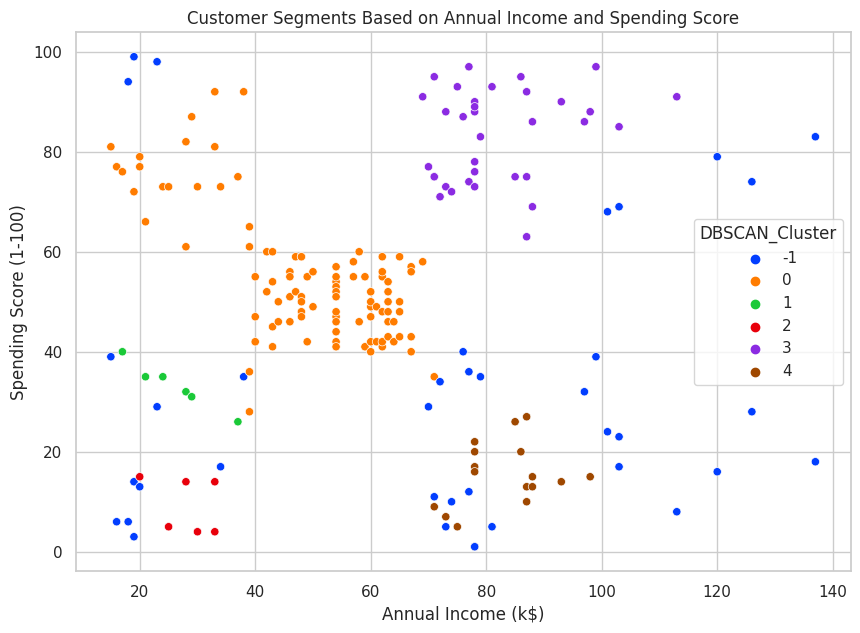

In [50]:
# Visualize Clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', palette='bright')
plt.title('Customer Segments Based on Annual Income and Spending Score')
plt.show()

In [51]:
cluster_summary = df.groupby('DBSCAN_Cluster').agg(
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean'),
    Customer_Count=('Age', 'count')
)

# Display the cluster summary
print("\nCluster Summary:")
cluster_summary


Cluster Summary:


,Average_Age,Average_Income,Average_Spending_Score,Customer_Count
DBSCAN_Cluster,,,,
-1,37.054054,72.324324,33.756757,37
0,39.670000,49.150000,54.560000,100
1,37.000000,26.000000,33.166667,6
2,53.333333,28.166667,9.333333,6
3,32.882353,82.000000,83.235294,34
4,45.411765,82.823529,14.705882,17


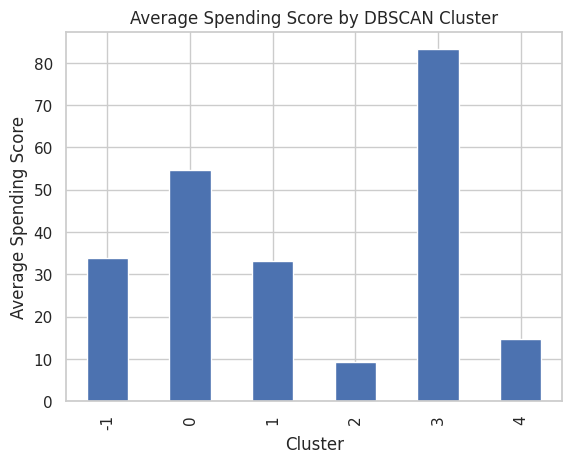

In [52]:
# Bar plot of average spending score by cluster
df.groupby('DBSCAN_Cluster')['Spending Score (1-100)'].mean().plot(kind='bar')
plt.title('Average Spending Score by DBSCAN Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Spending Score')
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 Results:</font></h3>

   The K-means cluster is the most suitable one, it cluster the customers into 5 clusters.

In [53]:
df = df.drop(columns=['Agglomerative_Cluster', 'DBSCAN_Cluster'])
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,19,15,39,0
1,1,21,15,81,4
2,0,20,16,6,0
3,0,23,16,77,4
4,0,31,17,40,0


In [54]:
df.to_csv('customer_segments.csv', index=False)